# 03 — Algoritmos Genéticos: ubicación de hospitales

**Curso:** Inteligencia Artificial — Optimización

Usaremos el mismo problema de Hill Climbing y Simulated Annealing:

> Ubicar varios hospitales en una cuadrícula para minimizar la distancia total de las casas al hospital más cercano.

## Objetivos

- representar una solución mediante un cromosoma;
- implementar selección, cruce y mutación;
- observar la evolución de una población;
- comparar el mejor individuo y el fitness medio.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

## 1. Problema

Para cada casa $h$, calculamos su distancia al hospital más cercano:

$$
C(H)=
\sum_{h\in\text{casas}}
\min_{p\in H}
d_{\text{Manhattan}}(h,p)
$$

Queremos minimizar $C(H)$.

Como los algoritmos genéticos suelen expresarse como maximización, definimos:

$$
\text{fitness}(H)=-C(H)
$$

Por tanto, un fitness mayor representa una solución de menor costo.

In [2]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(
        min(manhattan(house, hospital) for hospital in hospitals)
        for house in houses
    )


def fitness(individual, houses):
    return -total_cost(houses, individual)


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        rows, cols = zip(*houses)
        ax.scatter(cols, rows, marker="s", s=110, label="Casas")

    if hospitals:
        rows, cols = zip(*hospitals)
        ax.scatter(cols, rows, marker="P", s=180, label="Hospitales")

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f"Costo = {total_cost(houses, hospitals)}")
    plt.tight_layout()
    plt.show()

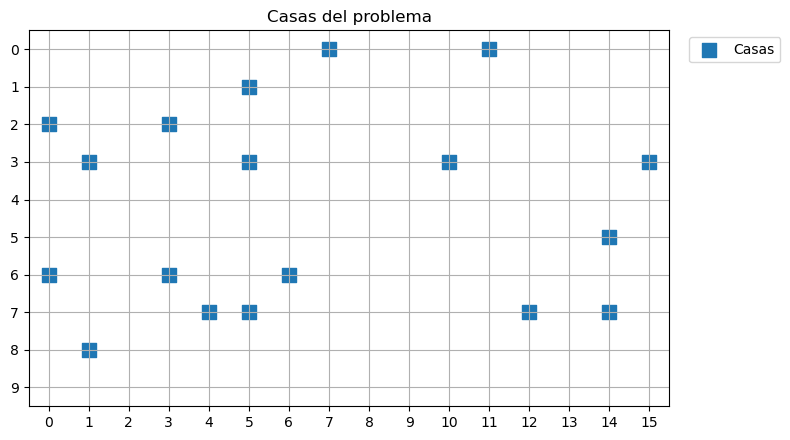

In [3]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [
    (row, col)
    for row in range(HEIGHT)
    for col in range(WIDTH)
]

rng = random.Random(SEED)

houses = set(rng.sample(all_cells, NUM_HOUSES))
valid_hospital_cells = [
    cell for cell in all_cells
    if cell not in houses
]

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    hospitals=[],
    title="Casas del problema",
)

## 2. Representación del cromosoma

Cada individuo contiene las posiciones de los hospitales:

```python
[(fila_1, columna_1), (fila_2, columna_2), (fila_3, columna_3)]
```

Restricciones de la representación:

- ningún hospital puede ubicarse sobre una casa;
- dos hospitales no pueden ocupar la misma celda.

Individuo: [(3, 8), (7, 6), (1, 9)]
Costo: 87
Fitness: -87


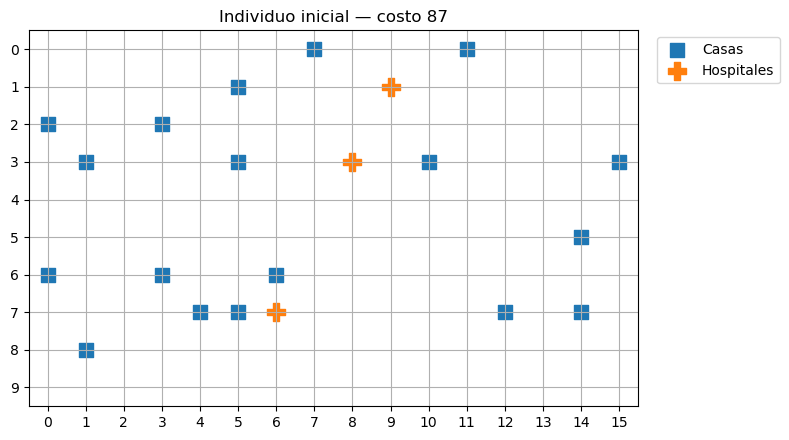

In [4]:
def create_individual(valid_cells, num_hospitals, rng):
    return rng.sample(valid_cells, num_hospitals)


example = create_individual(
    valid_hospital_cells,
    NUM_HOSPITALS,
    rng,
)

print("Individuo:", example)
print("Costo:", total_cost(houses, example))
print("Fitness:", fitness(example, houses))

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    example,
    title=f"Individuo inicial — costo {total_cost(houses, example)}",
)

## 3. Población inicial

Un algoritmo genético no mantiene una única solución, sino una población de soluciones candidatas.

In [5]:
def create_population(
    population_size,
    valid_cells,
    num_hospitals,
    rng,
):
    return [
        create_individual(valid_cells, num_hospitals, rng)
        for _ in range(population_size)
    ]


population = create_population(
    population_size=10,
    valid_cells=valid_hospital_cells,
    num_hospitals=NUM_HOSPITALS,
    rng=rng,
)

for i, individual in enumerate(population[:5]):
    print(
        f"{i}: {individual} | "
        f"costo={total_cost(houses, individual)}"
    )

0: [(8, 14), (4, 4), (0, 5)] | costo=71
1: [(4, 13), (9, 7), (7, 7)] | costo=102
2: [(8, 11), (6, 14), (2, 1)] | costo=83
3: [(4, 11), (1, 11), (1, 2)] | costo=88
4: [(6, 15), (6, 13), (1, 14)] | costo=152


## 4. Selección por torneo

Se toman varios individuos al azar y se selecciona el de mayor fitness, es decir, el de menor costo.

In [6]:
def tournament_selection(
    population,
    houses,
    tournament_size,
    rng,
):
    contestants = rng.sample(
        population,
        tournament_size,
    )

    winner = max(
        contestants,
        key=lambda individual: fitness(individual, houses),
    )

    return winner.copy()


selected = tournament_selection(
    population,
    houses,
    tournament_size=3,
    rng=rng,
)

print("Seleccionado:", selected)
print("Costo:", total_cost(houses, selected))

Seleccionado: [(3, 13), (2, 9), (1, 2)]
Costo: 86


## 5. Cruce de un punto

Cada gen es la posición de un hospital.

Dos padres intercambian parte de sus posiciones. Después del cruce debemos reparar posibles hospitales repetidos.

In [7]:
def repair_individual(
    individual,
    valid_cells,
    num_hospitals,
    rng,
):
    repaired = []
    used = set()

    for cell in individual:
        if cell in valid_cells and cell not in used:
            repaired.append(cell)
            used.add(cell)

    available = [
        cell for cell in valid_cells
        if cell not in used
    ]

    while len(repaired) < num_hospitals:
        cell = rng.choice(available)
        repaired.append(cell)
        available.remove(cell)

    return repaired[:num_hospitals]


def one_point_crossover(
    parent1,
    parent2,
    crossover_rate,
    valid_cells,
    num_hospitals,
    rng,
):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, num_hospitals - 1)

    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]

    child1 = repair_individual(
        child1,
        valid_cells,
        num_hospitals,
        rng,
    )
    child2 = repair_individual(
        child2,
        valid_cells,
        num_hospitals,
        rng,
    )

    return child1, child2

In [8]:
parent1, parent2 = population[0], population[1]

child1, child2 = one_point_crossover(
    parent1,
    parent2,
    crossover_rate=1.0,
    valid_cells=valid_hospital_cells,
    num_hospitals=NUM_HOSPITALS,
    rng=rng,
)

print("Padre 1:", parent1)
print("Padre 2:", parent2)
print("Hijo 1 :", child1)
print("Hijo 2 :", child2)

Padre 1: [(8, 14), (4, 4), (0, 5)]
Padre 2: [(4, 13), (9, 7), (7, 7)]
Hijo 1 : [(8, 14), (4, 4), (7, 7)]
Hijo 2 : [(4, 13), (9, 7), (0, 5)]


## 6. Mutación

La mutación selecciona un hospital y lo mueve a una celda vecina válida.

Esto introduce diversidad y permite explorar configuraciones que no aparecen mediante el cruce.

In [9]:
def mutate(
    individual,
    mutation_rate,
    height,
    width,
    houses,
    rng,
):
    child = individual.copy()
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for index, hospital in enumerate(child):
        if rng.random() >= mutation_rate:
            continue

        candidates = []

        for dr, dc in moves:
            candidate = (
                hospital[0] + dr,
                hospital[1] + dc,
            )

            if not (
                0 <= candidate[0] < height
                and 0 <= candidate[1] < width
            ):
                continue

            if candidate in houses:
                continue

            if candidate in child:
                continue

            candidates.append(candidate)

        if candidates:
            child[index] = rng.choice(candidates)

    return child

In [10]:
before = example
after = mutate(
    before,
    mutation_rate=1.0,
    height=HEIGHT,
    width=WIDTH,
    houses=houses,
    rng=rng,
)

print("Antes :", before)
print("Después:", after)
print("Costo antes:", total_cost(houses, before))
print("Costo después:", total_cost(houses, after))

Antes : [(3, 8), (7, 6), (1, 9)]
Después: [(2, 8), (7, 7), (1, 10)]
Costo antes: 87
Costo después: 90


## 7. Algoritmo genético completo

Usaremos:

- selección por torneo;
- cruce de un punto;
- mutación local;
- elitismo: el mejor individuo pasa directamente a la siguiente generación.

In [11]:
def genetic_algorithm(
    houses,
    valid_cells,
    height,
    width,
    num_hospitals=3,
    population_size=80,
    generations=150,
    crossover_rate=0.9,
    mutation=mutate,
    mutation_rate=0.25,
    tournament_size=3,
    elitism=True,
    seed=0,
):
    rng = random.Random(seed)

    population = create_population(
        population_size,
        valid_cells,
        num_hospitals,
        rng,
    )

    history = []

    for generation in range(generations + 1):
        costs = [
            total_cost(houses, individual)
            for individual in population
        ]

        best_index = int(np.argmin(costs))
        best = population[best_index].copy()
        best_cost = costs[best_index]

        history.append({
            "generation": generation,
            "best_cost": best_cost,
            "mean_cost": float(np.mean(costs)),
            "diversity": (
                len({
                    tuple(sorted(individual))
                    for individual in population
                })
                / population_size
            ),
            "best_individual": best,
        })

        if generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection(
                population,
                houses,
                tournament_size,
                rng,
            )
            parent2 = tournament_selection(
                population,
                houses,
                tournament_size,
                rng,
            )

            child1, child2 = one_point_crossover(
                parent1,
                parent2,
                crossover_rate,
                valid_cells,
                num_hospitals,
                rng,
            )

            child1 = mutation(
                child1,
                mutation_rate,
                height,
                width,
                houses,
                rng,
            )
            child2 = mutation(
                child2,
                mutation_rate,
                height,
                width,
                houses,
                rng,
            )

            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]["best_individual"], history

Mejor individuo: [(2, 4), (4, 13), (7, 3)]
Costo: 56
Fitness: -56
Generaciones: 150


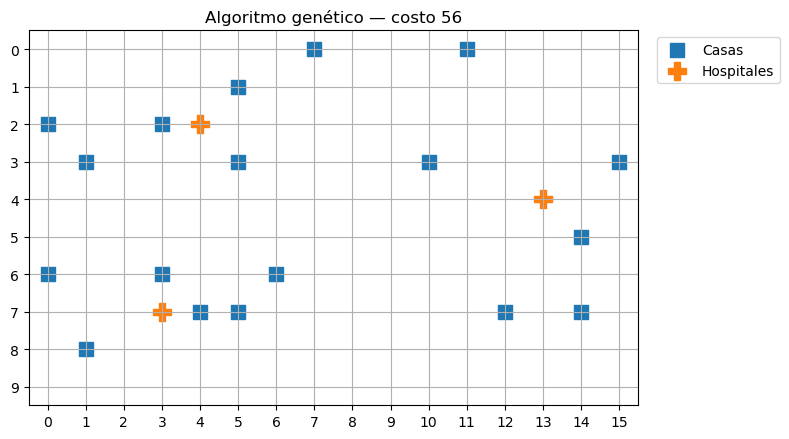

In [12]:
best, history = genetic_algorithm(
    houses=houses,
    valid_cells=valid_hospital_cells,
    height=HEIGHT,
    width=WIDTH,
    num_hospitals=NUM_HOSPITALS,
    seed=SEED,
)

best_cost = total_cost(houses, best)

print("Mejor individuo:", best)
print("Costo:", best_cost)
print("Fitness:", fitness(best, houses))
print("Generaciones:", history[-1]["generation"])

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    best,
    title=f"Algoritmo genético — costo {best_cost}",
)

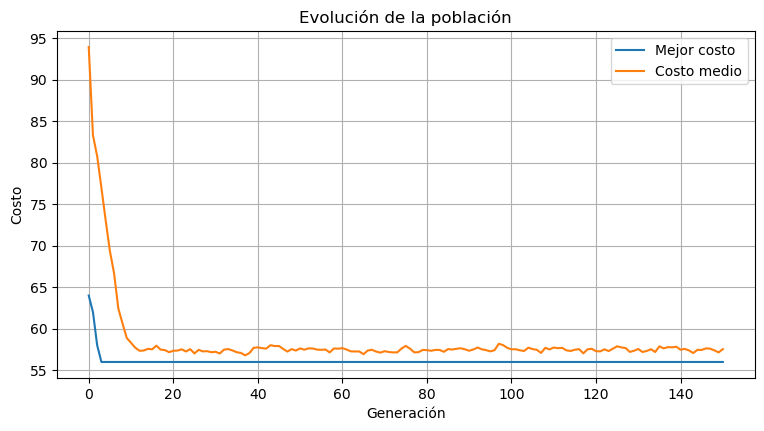

In [13]:
generations = [
    record["generation"]
    for record in history
]
best_costs = [
    record["best_cost"]
    for record in history
]
mean_costs = [
    record["mean_cost"]
    for record in history
]

plt.figure(figsize=(9, 4.5))
plt.plot(
    generations,
    best_costs,
    label="Mejor costo",
)
plt.plot(
    generations,
    mean_costs,
    label="Costo medio",
)
plt.xlabel("Generación")
plt.ylabel("Costo")
plt.title("Evolución de la población")
plt.legend()
plt.grid(True)
plt.show()

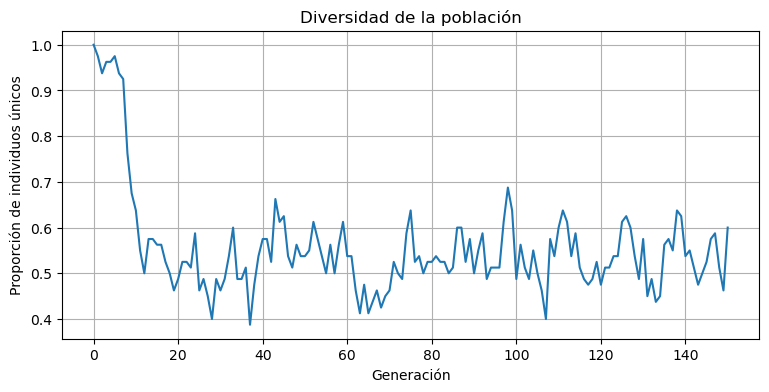

In [14]:
plt.figure(figsize=(9, 4))
plt.plot(
    generations,
    [record["diversity"] for record in history],
)
plt.xlabel("Generación")
plt.ylabel("Proporción de individuos únicos")
plt.title("Diversidad de la población")
plt.grid(True)
plt.show()

## 8. Efecto de la mutación

Una mutación muy baja puede producir convergencia prematura.

Una mutación muy alta puede impedir que la población conserve buenas configuraciones.

In [15]:
mutation_rates = [0.0, 0.05, 0.15, 0.30, 0.70]
summary = []

for rate in mutation_rates:
    final_costs = []

    for seed in range(15):
        solution, _ = genetic_algorithm(
            houses=houses,
            valid_cells=valid_hospital_cells,
            height=HEIGHT,
            width=WIDTH,
            num_hospitals=NUM_HOSPITALS,
            population_size=60,
            generations=100,
            mutation_rate=rate,
            seed=seed,
        )

        final_costs.append(
            total_cost(houses, solution)
        )

    summary.append({
        "mutation_rate": rate,
        "mean_cost": np.mean(final_costs),
        "best_cost": min(final_costs),
        "std_cost": np.std(final_costs),
    })

for row in summary:
    print(row)

{'mutation_rate': 0.0, 'mean_cost': np.float64(58.666666666666664), 'best_cost': 56, 'std_cost': np.float64(1.813529401164726)}
{'mutation_rate': 0.05, 'mean_cost': np.float64(56.333333333333336), 'best_cost': 56, 'std_cost': np.float64(0.5962847939999438)}
{'mutation_rate': 0.15, 'mean_cost': np.float64(56.06666666666667), 'best_cost': 56, 'std_cost': np.float64(0.24944382578492943)}
{'mutation_rate': 0.3, 'mean_cost': np.float64(56.0), 'best_cost': 56, 'std_cost': np.float64(0.0)}
{'mutation_rate': 0.7, 'mean_cost': np.float64(56.0), 'best_cost': 56, 'std_cost': np.float64(0.0)}


# Actividades

## Actividad 1 — Mutación global

Modifica `mutate()` para que un hospital pueda moverse a cualquier celda válida, no solamente a una celda vecina.

Compara:

- velocidad de convergencia;
- costo final;
- diversidad.

In [16]:
def mutate_global(
    individual,
    mutation_rate,
    height,
    width,
    houses,
    rng,
):
    child = individual.copy()

    for index in range(len(child)):
        if rng.random() >= mutation_rate:
            continue

        candidates = [
            (row, col)
            for row in range(height)
            for col in range(width)
            if (row, col) not in houses and (row, col) not in child
        ]

        if candidates:
            child[index] = rng.choice(candidates)

    return child

operator              mean cost    best   desv.  gen. conv.   diversity
local mutation            56.00      56    0.00        11.1       0.580
global mutation           56.00      56    0.00        18.8       0.740


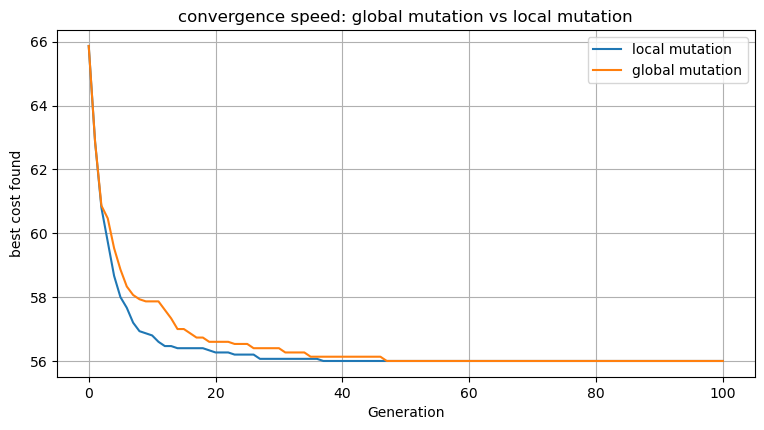

In [17]:
def convergence_generation(history):
    target = history[-1]["best_cost"]

    for record in history:
        if record["best_cost"] == target:
            return record["generation"]

    return history[-1]["generation"]

def evaluate_mutation(mutation, seeds=15):
    final_costs = []
    convergence = []
    diversities = []
    curves = []

    for seed in range(seeds):
        solution, history = genetic_algorithm(
            houses=houses,
            valid_cells=valid_hospital_cells,
            height=HEIGHT,
            width=WIDTH,
            num_hospitals=NUM_HOSPITALS,
            population_size=60,
            generations=100,
            mutation=mutation,
            seed=seed,
        )

        final_costs.append(
            total_cost(houses, solution)
        )
        convergence.append(
            convergence_generation(history)
        )
        diversities.append(
            history[-1]["diversity"]
        )
        curves.append([
            record["best_cost"]
            for record in history
        ])

    return {
        "mean_cost": np.mean(final_costs),
        "best_cost": min(final_costs),
        "std_cost": np.std(final_costs),
        "mean_convergence": np.mean(convergence),
        "mean_diversity": np.mean(diversities),
        "curves": curves,
    }

results = {
    'local mutation': evaluate_mutation(mutation=mutate),
    'global mutation': evaluate_mutation(mutation=mutate_global),
}

print(f'{"operator":<18} {"mean cost":>12} {"best":>7} {"desv.":>7} {"gen. conv.":>11} {"diversity":>11}')
for label, result in results.items():
    print(
        f'{label:<18} '
        f'{result["mean_cost"]:>12.2f} '
        f'{result["best_cost"]:>7} '
        f'{result["std_cost"]:>7.2f} '
        f'{result["mean_convergence"]:>11.1f} '
        f'{result["mean_diversity"]:>11.3f}'
    )

plt.figure(figsize=(9, 4.5))
for label, result in results.items():
    plt.plot(
        np.mean(result["curves"], axis=0),
        label=label,
    )
plt.xlabel("Generation")
plt.ylabel("best cost found")
plt.title("convergence speed: global mutation vs local mutation")
plt.legend()
plt.grid(True)
plt.show()

## Actividad 2 — Cruce uniforme

Para cada hospital, el hijo recibe la posición del padre 1 o del padre 2 con igual probabilidad.

Recuerda reparar hospitales repetidos.

In [18]:
def uniform_crossover(
    parent1,
    parent2,
    crossover_rate,
    valid_cells,
    num_hospitals,
    rng,
):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    child1 = []
    child2 = []

    for gene1, gene2 in zip(parent1, parent2):
        if rng.random() < 0.5:
            child1.append(gene1)
            child2.append(gene2)
        else:
            child1.append(gene2)
            child2.append(gene1)

    child1 = repair_individual(
        child1,
        valid_cells,
        num_hospitals,
        rng,
    )
    child2 = repair_individual(
        child2,
        valid_cells,
        num_hospitals,
        rng,
    )

    return child1, child2

In [19]:
demo_rng = random.Random(SEED)

parent1 = population[0]
parent2 = population[1]

child1, child2 = uniform_crossover(
    parent1,
    parent2,
    crossover_rate=1.0,
    valid_cells=valid_hospital_cells,
    num_hospitals=NUM_HOSPITALS,
    rng=demo_rng,
)

print("Padre 1:", parent1)
print("Padre 2:", parent2)
print("Hijo 1 :", child1)
print("Hijo 2 :", child2)

# el cruce posicional puede repetir un hospital; la reparación lo sustituye
broken = [parent1[0], parent1[0], parent1[1]]

print("\nCromosoma con hospital repetido:", broken)
print("Reparado:", repair_individual(
    broken,
    valid_hospital_cells,
    NUM_HOSPITALS,
    demo_rng,
))

# cuántos hijos distintos puede producir cada operador con los mismos padres
one_point_children = set()
uniform_children = set()

for _ in range(500):
    child, _ = one_point_crossover(
        parent1,
        parent2,
        1.0,
        valid_hospital_cells,
        NUM_HOSPITALS,
        demo_rng,
    )
    one_point_children.add(tuple(child))

    child, _ = uniform_crossover(
        parent1,
        parent2,
        1.0,
        valid_hospital_cells,
        NUM_HOSPITALS,
        demo_rng,
    )
    uniform_children.add(tuple(child))

print("\nHijos distintos con los mismos padres:")
print("  cruce de un punto:", len(one_point_children))
print("  cruce uniforme   :", len(uniform_children))

Padre 1: [(8, 14), (4, 4), (0, 5)]
Padre 2: [(4, 13), (9, 7), (7, 7)]
Hijo 1 : [(4, 13), (4, 4), (7, 7)]
Hijo 2 : [(8, 14), (9, 7), (0, 5)]

Cromosoma con hospital repetido: [(8, 14), (8, 14), (4, 4)]
Reparado: [(8, 14), (4, 4), (1, 8)]

Hijos distintos con los mismos padres:
  cruce de un punto: 2
  cruce uniforme   : 8


## Actividad 3 — Sin elitismo

Ejecuta el algoritmo con y sin elitismo.

Pregunta:

> ¿Puede aumentar el mejor costo de una generación a la siguiente cuando no usamos elitismo?

Con elitismo -> mejor costo final: 56
Sin elitismo -> mejor costo final: 56
¿Subió el mejor costo en algún punto sin elitismo? True


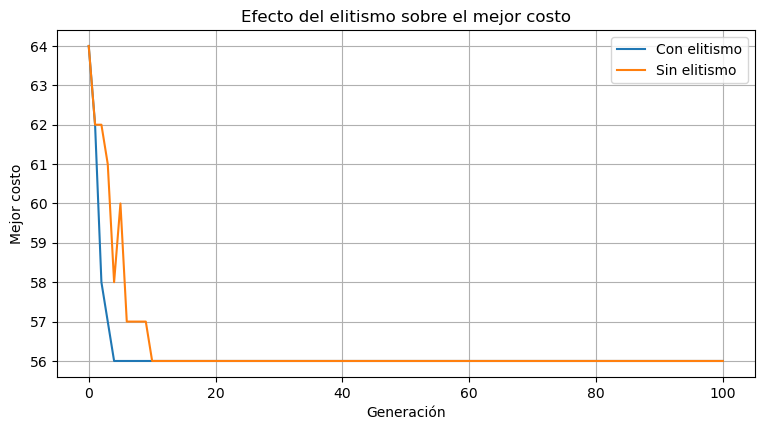

In [20]:
best_with, history_with = genetic_algorithm(
    houses=houses, valid_cells=valid_hospital_cells,
    height=HEIGHT, width=WIDTH, num_hospitals=NUM_HOSPITALS,
    population_size=60, generations=100, elitism=True, seed=SEED,
)
best_without, history_without = genetic_algorithm(
    houses=houses, valid_cells=valid_hospital_cells,
    height=HEIGHT, width=WIDTH, num_hospitals=NUM_HOSPITALS,
    population_size=60, generations=100, elitism=False, seed=SEED,
)

print('Con elitismo -> mejor costo final:', history_with[-1]['best_cost'])
print('Sin elitismo -> mejor costo final:', history_without[-1]['best_cost'])

increased = any(
    history_without[i]['best_cost'] > history_without[i - 1]['best_cost']
    for i in range(1, len(history_without))
)
print('¿Subió el mejor costo en algún punto sin elitismo?', increased)

plt.figure(figsize=(9, 4.5))
plt.plot([h['generation'] for h in history_with], [h['best_cost'] for h in history_with], label='Con elitismo')
plt.plot([h['generation'] for h in history_without], [h['best_cost'] for h in history_without], label='Sin elitismo')
plt.xlabel('Generación')
plt.ylabel('Mejor costo')
plt.title('Efecto del elitismo sobre el mejor costo')
plt.legend()
plt.grid(True)
plt.show()

Sí, puede aumentar. Como estamos minimizando el costo, "mejor" significa costo más bajo. Sin elitismo, el individuo de menor costo puede perderse entre una generación y la siguiente (no fue seleccionado en los torneos, o el cruce/reparación/mutación lo modificó), así que el mejor costo reportado puede subir temporalmente. Con elitismo, el mejor individuo siempre se conserva, por lo que el mejor costo nunca puede empeorar de una generación a otra.

## Actividad 4 — Comparación

Compara, usando las mismas casas:

- Hill Climbing;
- Simulated Annealing;
- Algoritmo Genético.

Realiza varias corridas y reporta:

- costo medio;
- mejor costo;
- desviación estándar;
- tiempo de ejecución.

In [21]:
import math
import time

def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue
            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors


def hill_climbing(height, width, houses, initial_state, max_iterations=200, rng=None):
    rng = rng or random.Random()
    current = set(initial_state)
    current_cost = total_cost(houses, current)
    history = [current_cost]

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(height, width, houses, current)
        if not neighbors:
            break

        costs = [total_cost(houses, neighbor) for neighbor in neighbors]
        best_cost = min(costs)
        if best_cost >= current_cost:
            break

        best_neighbors = [n for n, c in zip(neighbors, costs) if c == best_cost]
        current = set(rng.choice(best_neighbors))
        current_cost = best_cost
        history.append(current_cost)

    return current, history


def acceptance_probability(delta_cost, temperature):
    if delta_cost <= 0:
        return 1.0
    if temperature <= 0:
        return 0.0
    return math.exp(-delta_cost / temperature)


def simulated_annealing(
    height, width, houses, initial_state,
    iterations=1000, initial_temperature=20.0,
    cooling_rate=0.995, minimum_temperature=1e-3, rng=None,
):
    rng = rng or random.Random()
    current = set(initial_state)
    current_cost = total_cost(houses, current)
    best = set(current)
    best_cost = current_cost
    temperature = initial_temperature

    for _ in range(iterations):
        neighbors = neighbors_of_state(height, width, houses, current)
        if not neighbors or temperature < minimum_temperature:
            break

        candidate = set(rng.choice(neighbors))
        candidate_cost = total_cost(houses, candidate)
        delta_cost = candidate_cost - current_cost

        if rng.random() < acceptance_probability(delta_cost, temperature):
            current = candidate
            current_cost = candidate_cost
            if current_cost < best_cost:
                best = set(current)
                best_cost = current_cost

        temperature *= cooling_rate

    return best, best_cost


def random_initial_state(height, width, houses, num_hospitals, rng):
    cells = [(row, col) for row in range(height) for col in range(width) if (row, col) not in houses]
    return set(rng.sample(cells, num_hospitals))

algoritmo             costo medio   mejor   desv.   tiempo medio (s)
Hill Climbing               72.20      57   14.84             0.0021
Simulated Annealing         56.33      56    0.83             0.0376
Algoritmo Genético          56.03      56    0.18             0.6732


C:\Users\Ismael\AppData\Local\Temp\ipykernel_20016\1210243399.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([hc_costs, sa_costs, ga_costs], labels=['Hill Climbing', 'Simulated Annealing', 'Algoritmo Genético'])


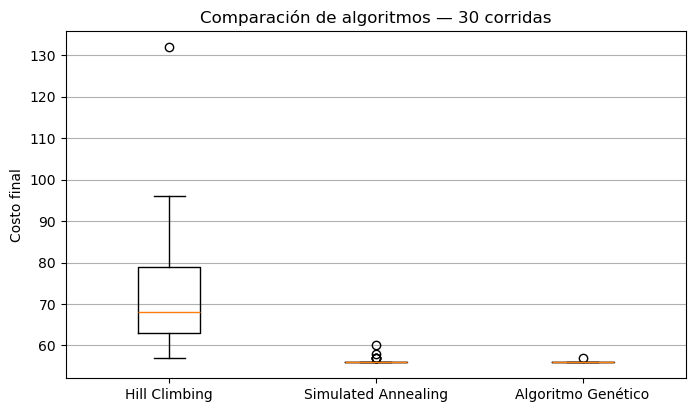

In [22]:
N_RUNS = 30
hc_costs, sa_costs, ga_costs = [], [], []
hc_times, sa_times, ga_times = [], [], []

for seed in range(N_RUNS):
    rng = random.Random(seed)
    start_state = random_initial_state(HEIGHT, WIDTH, houses, NUM_HOSPITALS, rng)

    t0 = time.perf_counter()
    _, hc_history = hill_climbing(HEIGHT, WIDTH, houses, start_state, rng=random.Random(seed))
    hc_times.append(time.perf_counter() - t0)
    hc_costs.append(hc_history[-1])

    t0 = time.perf_counter()
    _, sa_best_cost = simulated_annealing(
        HEIGHT, WIDTH, houses, start_state,
        iterations=1200, initial_temperature=20, cooling_rate=0.995,
        rng=random.Random(seed),
    )
    sa_times.append(time.perf_counter() - t0)
    sa_costs.append(sa_best_cost)

    t0 = time.perf_counter()
    ga_solution, _ = genetic_algorithm(
        houses=houses, valid_cells=valid_hospital_cells,
        height=HEIGHT, width=WIDTH, num_hospitals=NUM_HOSPITALS,
        population_size=60, generations=100, seed=seed,
    )
    ga_times.append(time.perf_counter() - t0)
    ga_costs.append(total_cost(houses, ga_solution))

summary = {
    'Hill Climbing': {'mean_cost': np.mean(hc_costs), 'best_cost': min(hc_costs), 'std_cost': np.std(hc_costs), 'mean_time': np.mean(hc_times)},
    'Simulated Annealing': {'mean_cost': np.mean(sa_costs), 'best_cost': min(sa_costs), 'std_cost': np.std(sa_costs), 'mean_time': np.mean(sa_times)},
    'Algoritmo Genético': {'mean_cost': np.mean(ga_costs), 'best_cost': min(ga_costs), 'std_cost': np.std(ga_costs), 'mean_time': np.mean(ga_times)},
}

print(f'{"algoritmo":<20} {"costo medio":>12} {"mejor":>7} {"desv.":>7} {"tiempo medio (s)":>18}')
for name, row in summary.items():
    print(f'{name:<20} {row["mean_cost"]:>12.2f} {row["best_cost"]:>7} {row["std_cost"]:>7.2f} {row["mean_time"]:>18.4f}')

plt.figure(figsize=(8, 4.5))
plt.boxplot([hc_costs, sa_costs, ga_costs], labels=['Hill Climbing', 'Simulated Annealing', 'Algoritmo Genético'])
plt.ylabel('Costo final')
plt.title('Comparación de algoritmos — 30 corridas')
plt.grid(True, axis='y')
plt.show()

## Preguntas de cierre

1. **¿Qué representa un gen en este problema?**

Un gen es la posición (fila, columna) de un solo hospital en la cuadrícula.

2. **¿Qué representa un cromosoma?**

Un cromosoma es una solución completa: la lista de posiciones de los `k` hospitales que se están ubicando simultáneamente (por ejemplo, `[(2,5), (7,1), (4,9)]` para 3 hospitales).

3. **¿Por qué el cruce puede producir hospitales repetidos?**

Porque el cruce de un punto (o el uniforme) toma genes (posiciones) de cada padre de forma independiente, sin verificar si esa posición ya fue tomada del otro padre. Si ambos padres tienen un hospital en la misma celda, o si el punto de corte junta posiciones que coinciden, el hijo puede terminar con dos hospitales en la misma coordenada, lo cual no es una solución válida (viola la restricción de que dos hospitales no pueden ocupar la misma celda).

4. **¿Qué función cumple la reparación?**

`repair_individual` detecta y elimina hospitales duplicados o inválidos (ubicados sobre una casa) en el cromosoma resultante del cruce, y reemplaza esas posiciones con celdas válidas y no repetidas elegidas al azar. Así garantiza que después del cruce siempre se obtenga un individuo válido, sin romper la lógica genérica de los operadores de cruce.

5. **¿Qué parámetros controlan exploración y explotación?**

- **Tasa de mutación (`mutation_rate`)**: mayor tasa mueve más hospitales a celdas vecinas al azar, favoreciendo exploración.
- **Tipo de mutación (local vs. global)**: la mutación local (mover a una celda vecina) explora de forma más conservadora; la mutación global (mover a cualquier celda válida) explora mucho más ampliamente pero de forma menos gradual.
- **Tamaño del torneo (`tournament_size`)**: torneos pequeños dan más peso a la exploración (permiten sobrevivir a individuos peores); torneos grandes aumentan la explotación (casi siempre gana el mejor).
- **Elitismo**: favorece la explotación al conservar siempre la mejor solución encontrada.
- **Tamaño de la población**: poblaciones grandes exploran más regiones del espacio en paralelo.

6. **¿Qué ventaja aporta mantener una población frente a Hill Climbing?**

Como se vio en la Actividad 4, Hill Climbing depende de un único estado inicial y del primer óptimo local que encuentra en su vecindario, lo que produce resultados muy variables (en la comparación tuvo una desviación estándar de 14.84 frente a 0.18 del Algoritmo Genético). Mantener una población permite explorar múltiples regiones del espacio de soluciones al mismo tiempo y combinar información de distintas soluciones parciales mediante el cruce, lo que hace que el resultado final sea mucho más consistente y menos dependiente de dónde empezó la búsqueda.